0 - Preparação com instalação e import das principais bibliotecas para execução do projeto\
*Antes de Importar instalar com pip install (pandas, numpy, metplotlib, seabor e ipykernel)\
*Os modulos (os, re, json, random e datetime) ja vem instalado no python

In [1]:
import os
import re
import json
import random
import jinja2
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Passo 1 - Criando Função para Gerar Dataframe sintetico e Gerando arquivo Vendas.csv

In [2]:
def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintético de vendas com dados intencionalmente sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse", "Headset"]
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares",
                  "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos",
                  "Headset": "Periféricos"}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco_base = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
                      "Monitor": 1200, "Teclado": 250, "Mouse": 120, "Headset": 350}[produto]
        preco = round(preco_base * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja)

        dados.append({
            "id_venda": i + 1,
            "data_venda": data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVÁLIDA",
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head())

Dataset gerado com 200 registros.
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celulares   Sudeste   
4         5  2024-07-12  Cliente_024       Mouse   Periféricos     Norte   

   quantidade  preco_unitario  
0         2.0          102.90  
1         7.0          214.88  
2         4.0             NaN  
3         4.0         2501.76  
4         8.0          121.30  


Passo 2 - Carregando e lendo o arquivo vendas.CSV

In [3]:
# Carregar e ler o arquivo CSV

caminho_csv = "vendas.csv"

df_carregado = pd.read_csv(caminho_csv)

print("Arquivo CSV carregado com sucesso.")
print(f"Nome do arquivo: {caminho_csv}")
print(f"Quantidade de linhas: {df_carregado.shape[0]}")
print(f"Quantidade de colunas: {df_carregado.shape[1]}")

print("\nColunas do dataset:")
print(list(df_carregado.columns))

print("\nPrimeiros registros do arquivo lido:")
display(df_carregado.head())

Arquivo CSV carregado com sucesso.
Nome do arquivo: vendas.csv
Quantidade de linhas: 200
Quantidade de colunas: 8

Colunas do dataset:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Primeiros registros do arquivo lido:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


Passo 3 - Criando Cópia de segurança do DataFrame carregado\

df_bruto      = # DataFrame gerado originalmente\
df_carregado  = # DataFrame lido a partir do vendas.csv\
df_original   = # Cópia preservada para segurança



In [4]:
# Cópia de segurança do DataFrame carregado

df_original = df_carregado.copy(deep=True)

print("Cópia de segurança criada com sucesso.")
print("Registros em df_carregado:", len(df_carregado))
print("Registros em df_original:", len(df_original))

Cópia de segurança criada com sucesso.
Registros em df_carregado: 200
Registros em df_original: 200


Passo 4 Criando Função e Exibindo as informações básicas do DataFrame de vendas.

In [5]:
def inspecionar_dados(df):
    """
    Exibe informações básicas do DataFrame de vendas.
    Esta função atende ao requisito RF02 do projeto.
    """

    print("\n" + "=" * 60)
    print("INSPEÇÃO INICIAL DO DATASET")
    print("=" * 60)

    print(f"\nShape do dataset: {df.shape}")

    print("\nColunas:")
    print(list(df.columns))

    print("\nTipos de dados:")
    print(df.dtypes)

    print("\nValores nulos por coluna:")
    print(df.isnull().sum().to_string())
    
    print("\nLinhas que possuem algum valor nulo:")
    print(df[df.isnull().any(axis=1)].head(10).to_string())

    print("\nPrimeiros 5 registros:")
    print(df.head())

    print("\nEstatísticas descritivas das colunas numéricas:")
    print(df.describe())
    

In [6]:
inspecionar_dados(df_carregado)


INSPEÇÃO INICIAL DO DATASET

Shape do dataset: (200, 8)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10

Linhas que possuem algum valor nulo:
    id_venda  data_venda      cliente     produto     categoria        regiao  quantidade  preco_unitario
2          3  2024-05-22  Cliente_022     Monitor  Computadores      Nordeste         4.0             NaN
34        35  2024-01-23  Cliente_048       Mouse   Periféricos  Centro-Oeste         NaN          131.86
38        39  2024-03-31  Cliente_027  

Passo 5 - Inspeção extra para analisar resultado invalidos e ou nulos

In [7]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", 100)

print("=== VALORES NULOS POR COLUNA ===")
print(df_carregado.isnull().sum().to_string())

print("\n=== TOTAL DE LINHAS COM ALGUM VALOR NULO ===")
print(df_carregado.isnull().any(axis=1).sum())

print("\n=== LINHAS COM VALORES NULOS ===")
display(df_carregado[df_carregado.isnull().any(axis=1)].head(20))

print("\n=== DATAS INVÁLIDAS EM TEXTO ===")
print((df_carregado["data_venda"] == "DATA INVÁLIDA").sum())

print("\n=== LINHAS COM DATA INVÁLIDA ===")
display(df_carregado[df_carregado["data_venda"] == "DATA INVÁLIDA"].head(20))

=== VALORES NULOS POR COLUNA ===
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10

=== TOTAL DE LINHAS COM ALGUM VALOR NULO ===
16

=== LINHAS COM VALORES NULOS ===


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
34,35,2024-01-23,Cliente_048,Mouse,Periféricos,Centro-Oeste,NaN,131.86
38,39,2024-03-31,Cliente_027,Headset,Periféricos,Sul,3.0,NaN
39,40,2024-02-25,Cliente_030,Tablet,Celulares,Nordeste,3.0,NaN
41,42,2024-10-01,Cliente_038,Mouse,Periféricos,Nordeste,9.0,NaN
43,44,2024-08-11,Cliente_048,Smartphone,Celulares,Sul,NaN,1899.30
62,63,2024-05-06,Cliente_043,Headset,Periféricos,Sudeste,1.0,NaN
69,70,2024-12-08,Cliente_014,Headset,Periféricos,Nordeste,8.0,NaN
75,76,2024-06-03,Cliente_036,Tablet,Celulares,Nordeste,NaN,1724.88
76,77,2024-09-08,Cliente_022,Mouse,Periféricos,Sul,3.0,NaN



=== DATAS INVÁLIDAS EM TEXTO ===
4

=== LINHAS COM DATA INVÁLIDA ===


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
56,57,DATA INVÁLIDA,Cliente_049,Monitor,Computadores,Norte,1.0,1094.46
91,92,DATA INVÁLIDA,Cliente_027,Notebook,Computadores,Sudeste,1.0,3996.80
94,95,DATA INVÁLIDA,Cliente_047,Headset,Periféricos,Nordeste,2.0,326.51
167,168,DATA INVÁLIDA,Cliente_023,Teclado,Periféricos,Sul,9.0,213.73


Passo 6 - Criando Função de Limpesa e Ajuste de dados invalidos e nulos


In [8]:
def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.

    Tratamentos realizados:
    1. Remove espaços extras das colunas de texto.
    2. Converte data_venda para datetime.
    3. Remove linhas com datas inválidas.
    4. Substitui quantidade nula por 1.
    5. Substitui preco_unitario nulo pela média do preço do mesmo produto.
    6. Remove linhas em que não foi possível calcular preço médio do produto.
    7. Ajusta os tipos numéricos finais.
    """

    n_inicial = len(df)
    relatorio = {}

    # 1. Remover espaços extras em colunas de texto
    colunas_texto = ["data_venda", "cliente", "produto", "categoria", "regiao"]

    for col in colunas_texto:
        df[col] = df[col].astype(str).str.strip()

    # 2. Converter data_venda para datetime
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    # 3. Remover datas inválidas
    n_datas_invalidas = df["data_venda"].isnull().sum()
    df = df.dropna(subset=["data_venda"]).copy()

    relatorio["datas_invalidas_removidas"] = int(n_datas_invalidas)

    # 4. Identificar valores nulos antes da imputação
    quantidades_nulas = df["quantidade"].isnull().sum()
    precos_nulos = df["preco_unitario"].isnull().sum()

    # 5. Substituir quantidade nula por 1
    df["quantidade"] = df["quantidade"].fillna(1)

    # 6. Calcular média de preço por produto
    media_preco_por_produto = df.groupby("produto")["preco_unitario"].transform("mean")

    # 7. Substituir preço nulo pela média do mesmo produto
    df["preco_unitario"] = df["preco_unitario"].fillna(media_preco_por_produto)

    # 8. Verificar preços que continuaram nulos
    precos_sem_media = df["preco_unitario"].isnull().sum()

    # 9. Remover linhas sem preço recuperável
    df = df.dropna(subset=["preco_unitario"]).copy()

    relatorio["quantidades_nulas_substituidas"] = int(quantidades_nulas)
    relatorio["precos_nulos_encontrados"] = int(precos_nulos)
    relatorio["precos_nulos_substituidos_por_media_do_produto"] = int(precos_nulos - precos_sem_media)
    relatorio["linhas_removidas_por_preco_sem_media"] = int(precos_sem_media)

    # 10. Garantir tipos numéricos corretos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # 11. Relatório final
    n_final = len(df)

    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = n_final
    relatorio["registros_removidos_total"] = n_inicial - n_final

    print("\n=== RELATÓRIO DE LIMPEZA ===")

    for chave, valor in relatorio.items():
        print(f"{chave}: {valor}")

    print("\nValores nulos após a limpeza:")
    print(df.isnull().sum().to_string())

    print("\nTipos de dados após a limpeza:")
    print(df.dtypes)

    return df, relatorio

Passo 7 - Executando Limpesa do DataFrame Carregado

In [9]:
df_limpo, relatorio_limpeza = limpar_dados(df_carregado.copy())

display(df_limpo.head())


=== RELATÓRIO DE LIMPEZA ===
datas_invalidas_removidas: 4
quantidades_nulas_substituidas: 6
precos_nulos_encontrados: 10
precos_nulos_substituidos_por_media_do_produto: 10
linhas_removidas_por_preco_sem_media: 0
registros_iniciais: 200
registros_finais: 196
registros_removidos_total: 4

Valores nulos após a limpeza:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0

Tipos de dados após a limpeza:
id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade                 int64
preco_unitario           float64
dtype: object


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.900000
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.880000
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4,1204.981481
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.760000
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.300000


In [10]:
# Lendo DataFrame limpo para análise
df_limpo


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.900000
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.880000
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4,1204.981481
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.760000
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.300000
...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.720000
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.830000
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.600000
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.420000


* Observação a coluna data, o formato esta no padrão EUA alterar somente para fins de relatorio e graficos

Passo 9 - Analise de clientes Unicos e Quantidade de Venda por cliente

In [11]:
quantidade_clientes_unicos = df_limpo["cliente"].nunique()
total_registros = len(df_limpo)


print(f"Quantidade de clientes únicos: {quantidade_clientes_unicos}")

tabela_clientes = (
    df_limpo["cliente"]
    .value_counts()
    .reset_index()
)

tabela_clientes.columns = ["cliente", "quantidade_de_vendas"]
tabela_clientes["quantidade_de_vendas"] = tabela_clientes["quantidade_de_vendas"].apply(lambda x: "1 Venda" if x == 1 else f"{x} Vendas")


display(tabela_clientes)

Quantidade de clientes únicos: 49


,cliente,quantidade_de_vendas
0,Cliente_024,8 Vendas
1,Cliente_021,8 Vendas
2,Cliente_015,8 Vendas
3,Cliente_035,7 Vendas
4,Cliente_043,7 Vendas
5,Cliente_048,7 Vendas
6,Cliente_005,6 Vendas
7,Cliente_023,6 Vendas
8,Cliente_044,6 Vendas
9,Cliente_007,6 Vendas


Passo 10 - Criando Função para Criar Colunas derivadas no DataSet df_limpo
* Colunas Criadas
1. `receita_total` - Esta coluna apresenta o valor total do produto vendido no ticket
2. `mes` - Esta coluna apresenta o mês do ano em forma numerica da venda
3. `mes_nome` - Esta coluna apresenta o mês do ano em forma textual da venda
4. `trimestre` - Esta coluna apresenta trimeste do ano abreviado 
5. `ano` - Esta coluna apresenta o ano em forma numerica
6. `faixa_receita_item` - Esta coluna apresenta a faixa de receita do item segundo a regra de classificação
7. `preco_medio_item`- Esta coluna apresenta o preço medio do item
8. `comparacao_preco_media` - Esta coluna apresenta o status do preço medio do item na venda (Abaixo, Acima ou Na media)
9. `percentual_diferenca_media` - Esta coluna apresenta o percentual de diferença do preço do item na venda

In [12]:
def criar_colunas_derivadas(df):
    """Cria colunas calculadas e derivadas a partir do dataset limpo."""

    from IPython.display import display

    df = df.copy()

    # Função para exibir valores monetários no padrão brasileiro
    def formatar_moeda_br(valor):
        if pd.isna(valor):
            return ""
        return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    # Faz os valores float aparecerem em R$ nas próximas visualizações simples
    pd.options.display.float_format = formatar_moeda_br

    # Função auxiliar para exibir DataFrames alinhados à esquerda nas próximas células
    def exibir_df(tabela, linhas=20):
        display(
            tabela
            .head(linhas)
            .style
            .set_properties(**{"text-align": "left"})
            .set_table_styles(
                [
                    {
                        "selector": "th",
                        "props": [("text-align", "left")]
                    }
                ]
            )
        )

    # Disponibiliza a função exibir_df para uso em outras células do notebook
    globals()["exibir_df"] = exibir_df

    # Garantir que data_venda esteja em formato datetime antes dos cálculos
    df["data_venda"] = pd.to_datetime(
        df["data_venda"],
        errors="coerce",
        dayfirst=True
    )

    # Receita total por linha
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Ajustar valores monetários para duas casas decimais
    df["preco_unitario"] = df["preco_unitario"].round(2)
    df["receita_total"] = df["receita_total"].round(2)

    # Colunas de data
    df["mes"] = df["data_venda"].dt.month

    meses_pt_br = {
        1: "Janeiro",
        2: "Fevereiro",
        3: "Março",
        4: "Abril",
        5: "Maio",
        6: "Junho",
        7: "Julho",
        8: "Agosto",
        9: "Setembro",
        10: "Outubro",
        11: "Novembro",
        12: "Dezembro"
    }

    df["mes_nome"] = df["mes"].map(meses_pt_br)

    # Trimestre usando T em vez de Q
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"T{q}")

    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita por item
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    classificacoes = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["faixa_receita_item"] = np.select(
        condicoes,
        classificacoes,
        default="Não Classificado"
    )

    # Média do preço unitário por produto
    df["preco_medio_item"] = (
        df.groupby("produto")["preco_unitario"]
        .transform("mean")
        .round(2)
    )

    # Comparação do preço da venda com a média do produto
    df["comparacao_preco_media"] = np.select(
        [
            df["preco_unitario"] > df["preco_medio_item"],
            df["preco_unitario"] < df["preco_medio_item"],
            df["preco_unitario"] == df["preco_medio_item"]
        ],
        [
            "Acima",
            "Abaixo",
            "Na média"
        ],
        default="Não classificado"
    )

    # Percentual acima ou abaixo da média
    df["percentual_diferenca_media"] = (
        (df["preco_unitario"] - df["preco_medio_item"]) / df["preco_medio_item"] * 100
    ).round(2)

    # Formatar percentual no padrão brasileiro com símbolo %
    df["percentual_diferenca_media"] = df["percentual_diferenca_media"].apply(
        lambda x: f"{x:.2f} %".replace(".", ",")
    )

    # Substituir data_venda para padrão brasileiro no final
    df["data_venda"] = df["data_venda"].dt.strftime("%d/%m/%Y")

    print("\n=== COLUNAS DERIVADAS CRIADAS ===")

    colunas_exibicao = [
        "data_venda",
        "produto",
        "preco_unitario",
        "receita_total",
        "mes",
        "mes_nome",
        "trimestre",
        "ano",
        "faixa_receita_item",
        "preco_medio_item",
        "comparacao_preco_media",
        "percentual_diferenca_media"
    ]

    colunas_monetarias = {
        "preco_unitario": formatar_moeda_br,
        "receita_total": formatar_moeda_br,
        "preco_medio_item": formatar_moeda_br
    }

    display(
        df[colunas_exibicao]
        .head()
        .style
        .format(colunas_monetarias)
        .set_properties(**{"text-align": "left"})
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [("text-align", "left")]
                }
            ]
        )
    )

    return df

Passo 11 - Criando Colunas Derivadas no df_limpo

In [13]:
df_limpo = criar_colunas_derivadas(df_limpo)


=== COLUNAS DERIVADAS CRIADAS ===


,data_venda,produto,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media
0,20/05/2024,Mouse,"R$ 102,90","R$ 205,80",5,Maio,T2,2024,Baixo Valor,"R$ 121,82",Abaixo,"-15,53 %"
1,17/02/2024,Teclado,"R$ 214,88","R$ 1.504,16",2,Fevereiro,T1,2024,Médio Valor,"R$ 242,19",Abaixo,"-11,28 %"
2,22/05/2024,Monitor,"R$ 1.204,98","R$ 4.819,93",5,Maio,T2,2024,Médio Valor,"R$ 1.204,98",Na média,"0,00 %"
3,21/06/2024,Smartphone,"R$ 2.501,76","R$ 10.007,04",6,Junho,T2,2024,Alto Valor,"R$ 2.167,12",Acima,"15,44 %"
4,12/07/2024,Mouse,"R$ 121,30","R$ 970,40",7,Julho,T3,2024,Médio Valor,"R$ 121,82",Abaixo,"-0,43 %"


Passo 12 - Criando Função para Calcular Metricas de Vendas (Por Mês, Top Produtos, Por Categoria, Por Região e Por Trimeste)

In [26]:
def calcular_metricas(df):
    """Calcula e retorna métricas agregadas do dataset."""

    metricas = {}

    por_mes = df.groupby("mes").agg(
        receita_total=("receita_total", "sum"),
        quantidade=("quantidade", "sum"),
        n_vendas=("id_venda", "count")
    ).reset_index().sort_values("mes")

    metricas["por_mes"] = por_mes

    top_produtos = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    metricas["top_produtos"] = top_produtos

    por_categoria = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    metricas["por_categoria"] = por_categoria

    por_regiao = df.groupby("regiao").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)
    
    metricas["por_regiao"] = por_regiao
    
    por_trimestre = df.groupby("trimestre").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)

    metricas["por_trimestre"] = por_trimestre

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        display(tabela)

    return metricas

In [27]:
metricas = calcular_metricas(df_limpo)


=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,"R$ 47.301,20",46,10
1,2,"R$ 75.342,20",94,16
2,3,"R$ 128.796,85",92,19
3,4,"R$ 103.611,52",75,15
4,5,"R$ 132.570,78",100,17
5,6,"R$ 119.059,73",76,16
6,7,"R$ 110.935,66",99,19
7,8,"R$ 142.461,63",83,15
8,9,"R$ 90.992,72",66,11
9,10,"R$ 138.446,52",127,21



=== TOP PRODUTOS ===


,produto,receita_total
0,Notebook,"R$ 381.173,55"
1,Tablet,"R$ 360.275,04"
2,Smartphone,"R$ 236.876,48"
3,Monitor,"R$ 195.286,34"
4,Headset,"R$ 62.822,19"



=== POR CATEGORIA ===


,categoria,receita_total
0,Celulares,"R$ 597.151,52"
1,Computadores,"R$ 576.459,89"
2,Periféricos,"R$ 112.082,91"



=== POR REGIAO ===


,regiao,receita_total,media_ticket
3,Sudeste,"R$ 331.034,10","R$ 7.698,47"
2,Norte,"R$ 252.849,55","R$ 7.023,60"
0,Centro-Oeste,"R$ 248.273,50","R$ 5.911,27"
1,Nordeste,"R$ 235.677,50","R$ 5.891,94"
4,Sul,"R$ 217.859,67","R$ 6.224,56"



=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,"R$ 355.242,03","R$ 7.400,88"
2,T3,"R$ 344.390,01","R$ 7.653,11"
3,T4,"R$ 334.622,03","R$ 5.769,35"
0,T1,"R$ 251.440,25","R$ 5.587,56"


In [30]:
def segmentar_clientes(df):
    """Segmenta clientes pelo total gasto e mostra quantidade de peças compradas."""

    clientes = (
        df.groupby("cliente")
        .agg(
            total_gasto=("receita_total", "sum"),
            quantidade_pecas_compradas=("quantidade", "sum"),
            quantidade_de_compras=("id_venda", "count")
        )
        .reset_index()
    )

    clientes["total_gasto"] = clientes["total_gasto"].round(2)
    clientes["quantidade_pecas_compradas"] = clientes["quantidade_pecas_compradas"].astype(int)

    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda gasto: "Ouro" if gasto > 15000
        else ("Prata" if gasto >= 5000 else "Bronze")
    )

    clientes = clientes.sort_values("total_gasto", ascending=False)

    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    display(clientes.head(10))

    print("\nDistribuição de segmentos:")
    print(clientes["segmento"].value_counts())

    return clientes

In [31]:
clientes_segmentados = segmentar_clientes(df_limpo)


=== SEGMENTAÇÃO DE CLIENTES ===


,cliente,total_gasto,quantidade_pecas_compradas,quantidade_de_compras,segmento
13,Cliente_015,"R$ 82.964,76",52,8,Ouro
33,Cliente_035,"R$ 75.402,52",44,7,Ouro
46,Cliente_048,"R$ 64.324,93",33,7,Ouro
22,Cliente_024,"R$ 57.381,21",56,8,Ouro
5,Cliente_006,"R$ 50.249,74",43,6,Ouro
3,Cliente_004,"R$ 50.106,56",25,5,Ouro
21,Cliente_023,"R$ 46.863,73",26,6,Ouro
28,Cliente_030,"R$ 45.659,41",26,5,Ouro
30,Cliente_032,"R$ 45.532,00",26,4,Ouro
42,Cliente_044,"R$ 43.513,88",36,6,Ouro



Distribuição de segmentos:
segmento
Ouro      32
Prata      9
Bronze     8
Name: count, dtype: int64


In [32]:
def calcular_estatisticas_numpy(df):
    """Usa NumPy para calcular estatísticas sobre as receitas."""

    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    receitas = df["receita_total"].to_numpy()

    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    p25 = np.percentile(receitas, 25)
    p75 = np.percentile(receitas, 75)

    print(f"Receita média por venda: R$ {media:.2f}")
    print(f"Receita mediana por venda: R$ {mediana:.2f}")
    print(f"Desvio padrão: R$ {desvio_padrao:.2f}")
    print(f"Receita total: R$ {total:.2f}")
    print(f"Percentil 25: R$ {p25:.2f}")
    print(f"Percentil 75: R$ {p75:.2f}")

    receitas_normalizadas = (receitas - receitas.min()) / (receitas.max() - receitas.min())

    print("\nReceitas normalizadas — primeiros 5 valores:")
    print(receitas_normalizadas[:5].round(4))

    acima_da_media = receitas[receitas > media]

    print(f"\nVendas acima da média: {len(acima_da_media)} de {len(receitas)}")

    return {
        "media": media,
        "mediana": mediana,
        "desvio_padrao": desvio_padrao,
        "total": total,
        "percentil_25": p25,
        "percentil_75": p75
    }

In [33]:
stats_numpy = calcular_estatisticas_numpy(df_limpo)


=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196


Este codigo é auxiliar para esclarecimento do Percentil 25 e 75

In [34]:
p25 = np.percentile(df_limpo["receita_total"], 25)
p75 = np.percentile(df_limpo["receita_total"], 75)

vendas_ate_p25 = (df_limpo["receita_total"] <= p25).sum()
vendas_ate_p75 = (df_limpo["receita_total"] <= p75).sum()

total_vendas = len(df_limpo)

print(f"Percentil 25: R$ {p25:.2f}")
print(f"Vendas até o percentil 25: {vendas_ate_p25} de {total_vendas}")

print(f"\nPercentil 75: R$ {p75:.2f}")
print(f"Vendas até o percentil 75: {vendas_ate_p75} de {total_vendas}")

Percentil 25: R$ 1096.07
Vendas até o percentil 25: 49 de 196

Percentil 75: R$ 10657.42
Vendas até o percentil 75: 147 de 196


Explicação auxiliar para entendimento da receita normalizada\
1ª venda: R$ 205,80    - 0.0024 → muito baixa em relação à maior venda\
2ª venda: R$ 1.504,16  - 0.0443 → baixa\
3ª venda: R$ 4.819,93  - 0.1512 → ainda baixa/moderada\
4ª venda: R$ 10.007,04 - 0.3184 → mais relevante, mas ainda longe da maior venda\
5ª venda: R$ 970,40    - 0.0270 → baixa



In [36]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """Gera e exporta visualizações dos dados de vendas."""

    os.makedirs(output_dir, exist_ok=True)

    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # Gráfico 1: Receita por mês
    fig, ax = plt.subplots()

    por_mes = metricas["por_mes"]

    ax.plot(
        por_mes["mes"],
        por_mes["receita_total"],
        marker="o",
        linewidth=2,
        color="#2196F3"
    )

    ax.fill_between(
        por_mes["mes"],
        por_mes["receita_total"],
        alpha=0.15,
        color="#2196F3"
    )

    ax.set_title("Receita Total por Mês - 2024")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(
        ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"],
        rotation=45
    )

    plt.tight_layout()

    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    # Gráfico 2: Top 5 produtos
    fig, ax = plt.subplots()

    top = metricas["top_produtos"]

    sns.barplot(
        data=top,
        y="produto",
        x="receita_total",
        ax=ax,
        palette="Blues_d"
    )

    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")

    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)

    plt.tight_layout()

    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    # Gráfico 3: Distribuição por região
    fig, ax = plt.subplots()

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax,
        palette="Set2"
    )

    ax.set_title("Distribuição de Receita por Transação - Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")

    plt.xticks(rotation=30)
    plt.tight_layout()

    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()

    print(f"Gráfico exportado: {caminho}")

    print("\n=== VISUALIZAÇÕES GERADAS COM SUCESSO ===")

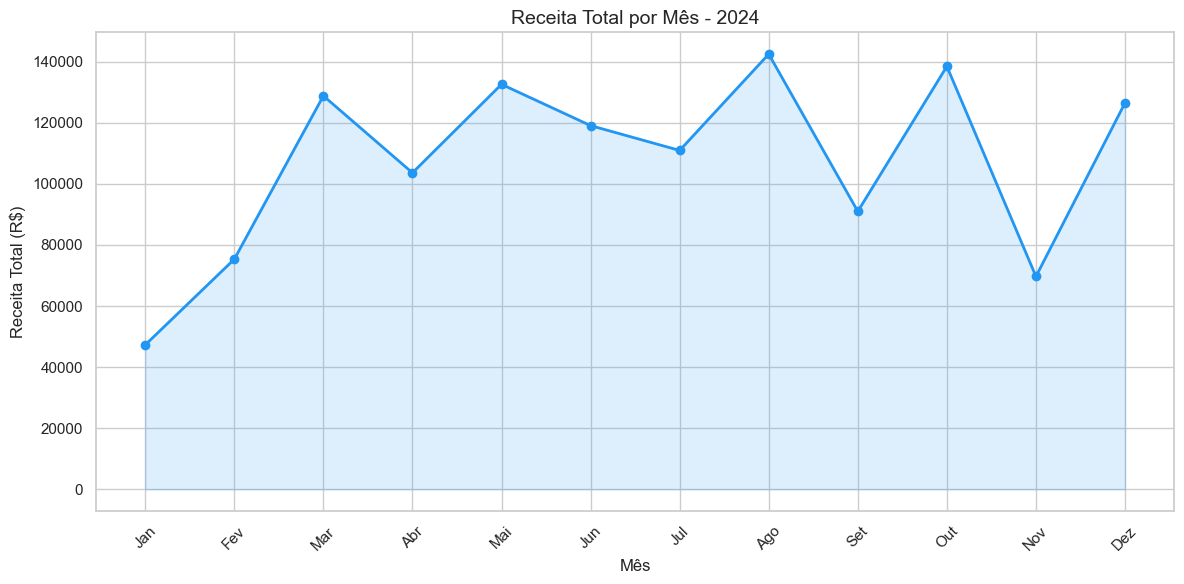

Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\renat\AppData\Local\Temp\ipykernel_22532\1160869401.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


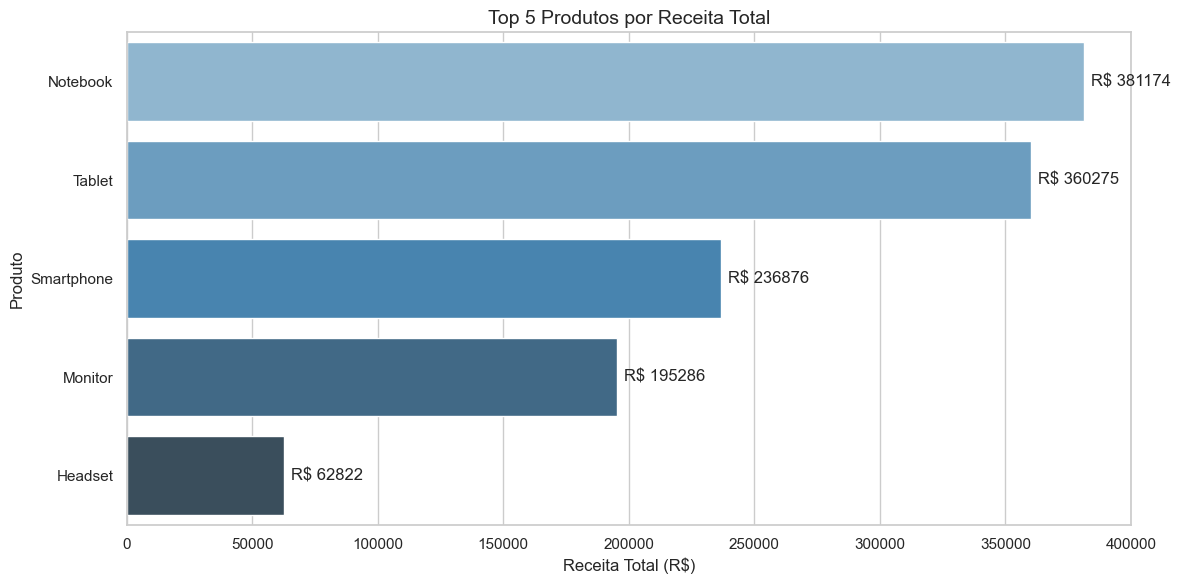

Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\renat\AppData\Local\Temp\ipykernel_22532\1160869401.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


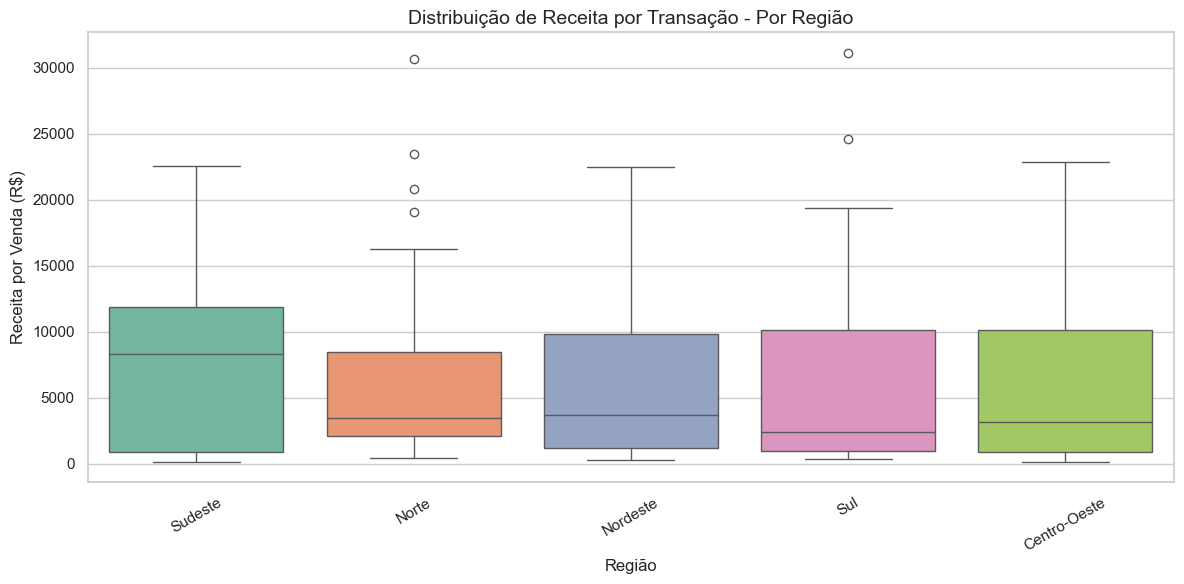

Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===


In [37]:
gerar_visualizacoes(df_limpo, metricas)

In [38]:
class AnalisadorDeVendas:
    """
    Classe responsável por encapsular o pipeline de análise de vendas.
    Mantém o estado do DataFrame e os resultados intermediários.
    """

    def __init__(self, caminho_arquivo):
        self.caminho_arquivo = caminho_arquivo
        self.df_bruto = None
        self.df_limpo = None
        self.metricas = {}
        self.clientes = None
        self.relatorio_limpeza = {}
        self.stats_numpy = None

    def carregar(self):
        self.df_bruto = pd.read_csv(self.caminho_arquivo)

        print(f"[AnalisadorDeVendas] Arquivo carregado: {self.caminho_arquivo}")
        print(f"Registros carregados: {len(self.df_bruto)}")

        return self

    def limpar(self):
        self.df_limpo, self.relatorio_limpeza = limpar_dados(self.df_bruto.copy())
        return self

    def transformar(self):
        self.df_limpo = criar_colunas_derivadas(self.df_limpo)
        return self

    def analisar(self):
        self.metricas = calcular_metricas(self.df_limpo)
        self.clientes = segmentar_clientes(self.df_limpo)
        self.stats_numpy = calcular_estatisticas_numpy(self.df_limpo)

        return self

    def visualizar(self):
        gerar_visualizacoes(self.df_limpo, self.metricas)
        return self

    def exportar_relatorio(self, caminho="outputs/relatorio_resumo.csv"):
        os.makedirs("outputs", exist_ok=True)

        self.metricas["por_mes"].to_csv(caminho, index=False, encoding="utf-8-sig")

        print(f"\n[AnalisadorDeVendas] Relatório exportado: {caminho}")

        return self

    def resumo(self):
        print("\n" + "=" * 50)
        print("RESUMO EXECUTIVO - SALESINSIGHT PY")
        print("=" * 50)

        print(f"Arquivo analisado: {self.caminho_arquivo}")
        print(f"Registros brutos: {self.relatorio_limpeza.get('registros_iniciais', 'N/A')}")
        print(f"Registros limpos: {self.relatorio_limpeza.get('registros_finais', 'N/A')}")

        receita = self.df_limpo["receita_total"].sum() if self.df_limpo is not None else 0

        print(f"Receita total anual: R$ {receita:,.2f}")

        if self.clientes is not None:
            top = self.clientes.iloc[0]
            print(f"Cliente top: {top['cliente']} - R$ {top['total_gasto']:,.2f}")

        print("=" * 50)

In [39]:
class AnalisadorComProjecao(AnalisadorDeVendas):
    """
    Extensão do AnalisadorDeVendas com funcionalidades de projeção simples.
    Herda todos os métodos da classe pai e adiciona projeção de tendência.
    """

    def __init__(self, caminho_arquivo, meses_projecao=3):
        super().__init__(caminho_arquivo)

        self.meses_projecao = meses_projecao
        self.projecoes = []

    def projetar_tendencia(self):
        """
        Projeta a receita dos próximos meses com base na média móvel dos últimos 3 meses.
        Método simples sem machine learning, baseado em médias.
        """

        if not self.metricas or "por_mes" not in self.metricas:
            print("[AVISO] Rode .analisar() antes de projetar.")
            return self

        por_mes = self.metricas["por_mes"].sort_values("mes")
        receitas_historicas = por_mes["receita_total"].to_numpy()

        ultimos_3 = receitas_historicas[-3:]
        media_movel = np.mean(ultimos_3)
        tendencia = np.std(ultimos_3) * 0.1

        ultimo_mes = int(por_mes["mes"].max())

        print("\n=== PROJEÇÃO DE TENDÊNCIA - MÉDIA MÓVEL SIMPLES ===")
        print(f"Base: média dos últimos 3 meses = R$ {media_movel:,.2f}")

        self.projecoes = []

        for i in range(1, self.meses_projecao + 1):
            mes_projetado = (ultimo_mes + i - 1) % 12 + 1
            receita_projetada = media_movel + (tendencia * i)

            self.projecoes.append({
                "mes": mes_projetado,
                "receita_projetada": round(receita_projetada, 2)
            })

            print(f"Mês {mes_projetado:02d}: R$ {receita_projetada:,.2f}")

        return self

    def exibir_projecao_detalhada(self):
        if not self.projecoes:
            print("[AVISO] Nenhuma projeção disponível. Rode .projetar_tendencia() primeiro.")
            return

        print("\n=== DETALHAMENTO DAS PROJEÇÕES ===")

        for p in self.projecoes:
            print(f"Mês {p['mes']:02d}: R$ {p['receita_projetada']:,.2f}")

In [40]:
def processar_coluna(df, coluna, funcao_transformacao):
    """
    Aplica uma função de transformação a uma coluna do DataFrame.
    Demonstra o uso de função como argumento.
    """

    df[f"{coluna}_transformado"] = df[coluna].apply(funcao_transformacao)

    print(f"Coluna '{coluna}_transformado' criada com sucesso.")

    return df

In [41]:
df_limpo = processar_coluna(
    df_limpo,
    "receita_total",
    lambda x: round(x / 1000, 2)
)

df_limpo = processar_coluna(
    df_limpo,
    "quantidade",
    lambda x: "Alto" if x > 5 else "Baixo"
)

display(df_limpo.head())

Coluna 'receita_total_transformado' criada com sucesso.
Coluna 'quantidade_transformado' criada com sucesso.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media,receita_total_transformado,quantidade_transformado
0,1,20/05/2024,Cliente_035,Mouse,Periféricos,Sudeste,2,"R$ 102,90","R$ 205,80",5,Maio,T2,2024,Baixo Valor,"R$ 121,82",Abaixo,"-15,53 %","R$ 0,21",Baixo
1,2,17/02/2024,Cliente_042,Teclado,Periféricos,Norte,7,"R$ 214,88","R$ 1.504,16",2,Fevereiro,T1,2024,Médio Valor,"R$ 242,19",Abaixo,"-11,28 %","R$ 1,50",Alto
2,3,22/05/2024,Cliente_022,Monitor,Computadores,Nordeste,4,"R$ 1.204,98","R$ 4.819,93",5,Maio,T2,2024,Médio Valor,"R$ 1.204,98",Na média,"0,00 %","R$ 4,82",Baixo
3,4,21/06/2024,Cliente_017,Smartphone,Celulares,Sudeste,4,"R$ 2.501,76","R$ 10.007,04",6,Junho,T2,2024,Alto Valor,"R$ 2.167,12",Acima,"15,44 %","R$ 10,01",Baixo
4,5,12/07/2024,Cliente_024,Mouse,Periféricos,Norte,8,"R$ 121,30","R$ 970,40",7,Julho,T3,2024,Médio Valor,"R$ 121,82",Abaixo,"-0,43 %","R$ 0,97",Alto


In [42]:
df_limpo["desconto"] = df_limpo["receita_total"].apply(
    lambda x: 0.10 if x > 10000 else 0.05
)

display(df_limpo[["receita_total", "desconto"]].head())

,receita_total,desconto
0,"R$ 205,80","R$ 0,05"
1,"R$ 1.504,16","R$ 0,05"
2,"R$ 4.819,93","R$ 0,05"
3,"R$ 10.007,04","R$ 0,10"
4,"R$ 970,40","R$ 0,05"


In [43]:
def exportar_resultados(metricas, clientes, stats_numpy):
    """Exporta resultados em CSV e JSON."""

    os.makedirs("outputs", exist_ok=True)

    caminho_csv = "outputs/metricas_por_mes.csv"
    metricas["por_mes"].to_csv(caminho_csv, index=False, encoding="utf-8-sig")

    print(f"CSV exportado: {caminho_csv}")

    caminho_clientes = "outputs/segmentacao_clientes.csv"
    clientes.to_csv(caminho_clientes, index=False, encoding="utf-8-sig")

    print(f"CSV exportado: {caminho_clientes}")

    caminho_json = "outputs/estatisticas_gerais.json"

    stats_serializaveis = {
        chave: round(float(valor), 2)
        for chave, valor in stats_numpy.items()
    }

    with open(caminho_json, "w", encoding="utf-8") as arquivo:
        json.dump(stats_serializaveis, arquivo, indent=4, ensure_ascii=False)

    print(f"JSON exportado: {caminho_json}")

    with open(caminho_json, "r", encoding="utf-8") as arquivo:
        dados_lidos = json.load(arquivo)

    print("\nConteúdo do JSON exportado:")
    print(json.dumps(dados_lidos, indent=2, ensure_ascii=False))

In [44]:
exportar_resultados(metricas, clientes_segmentados, stats_numpy)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media": 6559.66,
  "mediana": 3591.18,
  "desvio_padrao": 6625.37,
  "total": 1285694.32,
  "percentil_25": 1096.07,
  "percentil_75": 10657.42
}


In [45]:
def limpar_strings_com_regex(df):
    """
    Usa expressões regulares para limpeza de colunas de texto.
    Exemplo: limpar e validar nomes de clientes.
    """

    df["cliente_limpo"] = df["cliente"].apply(
        lambda s: re.sub(r"[^a-zA-Z0-9_ ]", "", str(s)).strip()
    )

    padrao_cliente = re.compile(r"^Cliente_\d{3}$")

    df["cliente_valido"] = df["cliente_limpo"].apply(
        lambda s: bool(padrao_cliente.match(s))
    )

    n_invalidos = (~df["cliente_valido"]).sum()

    print("\n=== LIMPEZA COM REGEX ===")
    print(f"Clientes com formato inválido encontrados: {n_invalidos}")
    print(f"Amostra de clientes limpos: {df['cliente_limpo'].head(5).tolist()}")

    return df

In [47]:
df_limpo = limpar_strings_com_regex(df_limpo)

display(df_limpo[["cliente", "cliente_limpo", "cliente_valido"]].head())


=== LIMPEZA COM REGEX ===
Clientes com formato inválido encontrados: 0
Amostra de clientes limpos: ['Cliente_035', 'Cliente_042', 'Cliente_022', 'Cliente_017', 'Cliente_024']


,cliente,cliente_limpo,cliente_valido
0,Cliente_035,Cliente_035,True
1,Cliente_042,Cliente_042,True
2,Cliente_022,Cliente_022,True
3,Cliente_017,Cliente_017,True
4,Cliente_024,Cliente_024,True


In [48]:
def main():
    """
    Função principal: executa o pipeline completo do SalesInsight PY.
    """

    print("\n" + "=" * 60)
    print("SALESINSIGHT PY - Pipeline de Análise de Dados de Vendas")
    print("=" * 60)

    if not os.path.exists("vendas.csv"):
        print("\n[INFO] Gerando dataset sintético...")

        df_gerado = gerar_dataset_vendas(n_registros=200)
        df_gerado.to_csv("vendas.csv", index=False, encoding="utf-8-sig")

    analisador = AnalisadorComProjecao("vendas.csv", meses_projecao=3)

    (
        analisador
        .carregar()
        .limpar()
        .transformar()
        .analisar()
        .projetar_tendencia()
        .visualizar()
        .exportar_relatorio()
    )

    analisador.df_limpo = limpar_strings_com_regex(analisador.df_limpo)

    stats = calcular_estatisticas_numpy(analisador.df_limpo)

    exportar_resultados(
        analisador.metricas,
        analisador.clientes,
        stats
    )

    analisador.resumo()
    analisador.exibir_projecao_detalhada()

    print("\n[CONCLUÍDO] Pipeline finalizado com sucesso!")


SALESINSIGHT PY - Pipeline de Análise de Dados de Vendas
[AnalisadorDeVendas] Arquivo carregado: vendas.csv
Registros carregados: 200

=== RELATÓRIO DE LIMPEZA ===
datas_invalidas_removidas: 4
quantidades_nulas_substituidas: 6
precos_nulos_encontrados: 10
precos_nulos_substituidos_por_media_do_produto: 10
linhas_removidas_por_preco_sem_media: 0
registros_iniciais: 200
registros_finais: 196
registros_removidos_total: 4

Valores nulos após a limpeza:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0

Tipos de dados após a limpeza:
id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade                 int64
preco_unitario           float64
dtype: object

=== COLUNAS DERIVADAS CRIADAS ===


,data_venda,produto,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,preco_medio_item,comparacao_preco_media,percentual_diferenca_media
0,20/05/2024,Mouse,"R$ 102,90","R$ 205,80",5,Maio,T2,2024,Baixo Valor,"R$ 121,82",Abaixo,"-15,53 %"
1,17/02/2024,Teclado,"R$ 214,88","R$ 1.504,16",2,Fevereiro,T1,2024,Médio Valor,"R$ 242,19",Abaixo,"-11,28 %"
2,22/05/2024,Monitor,"R$ 1.204,98","R$ 4.819,93",5,Maio,T2,2024,Médio Valor,"R$ 1.204,98",Na média,"0,00 %"
3,21/06/2024,Smartphone,"R$ 2.501,76","R$ 10.007,04",6,Junho,T2,2024,Alto Valor,"R$ 2.167,12",Acima,"15,44 %"
4,12/07/2024,Mouse,"R$ 121,30","R$ 970,40",7,Julho,T3,2024,Médio Valor,"R$ 121,82",Abaixo,"-0,43 %"



=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,"R$ 47.301,20",46,10
1,2,"R$ 75.342,20",94,16
2,3,"R$ 128.796,85",92,19
3,4,"R$ 103.611,52",75,15
4,5,"R$ 132.570,78",100,17
5,6,"R$ 119.059,73",76,16
6,7,"R$ 110.935,66",99,19
7,8,"R$ 142.461,63",83,15
8,9,"R$ 90.992,72",66,11
9,10,"R$ 138.446,52",127,21



=== TOP PRODUTOS ===


...


=== POR TRIMESTRE ===


,trimestre,receita_total,media_ticket
1,T2,"R$ 355.242,03","R$ 7.400,88"
2,T3,"R$ 344.390,01","R$ 7.653,11"
3,T4,"R$ 334.622,03","R$ 5.769,35"
0,T1,"R$ 251.440,25","R$ 5.587,56"



=== SEGMENTAÇÃO DE CLIENTES ===


,cliente,total_gasto,quantidade_pecas_compradas,quantidade_de_compras,segmento
13,Cliente_015,"R$ 82.964,76",52,8,Ouro
33,Cliente_035,"R$ 75.402,52",44,7,Ouro
46,Cliente_048,"R$ 64.324,93",33,7,Ouro
22,Cliente_024,"R$ 57.381,21",56,8,Ouro
5,Cliente_006,"R$ 50.249,74",43,6,Ouro
3,Cliente_004,"R$ 50.106,56",25,5,Ouro
21,Cliente_023,"R$ 46.863,73",26,6,Ouro
28,Cliente_030,"R$ 45.659,41",26,5,Ouro
30,Cliente_032,"R$ 45.532,00",26,4,Ouro
42,Cliente_044,"R$ 43.513,88",36,6,Ouro



Distribuição de segmentos:
segmento
Ouro      32
Prata      9
Bronze     8
Name: count, dtype: int64

=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196

=== PROJEÇÃO DE TENDÊNCIA - MÉDIA MÓVEL SIMPLES ===
Base: média dos últimos 3 meses = R$ 111,540.68
Mês 01: R$ 114,540.02
Mês 02: R$ 117,539.35
Mês 03: R$ 120,538.69


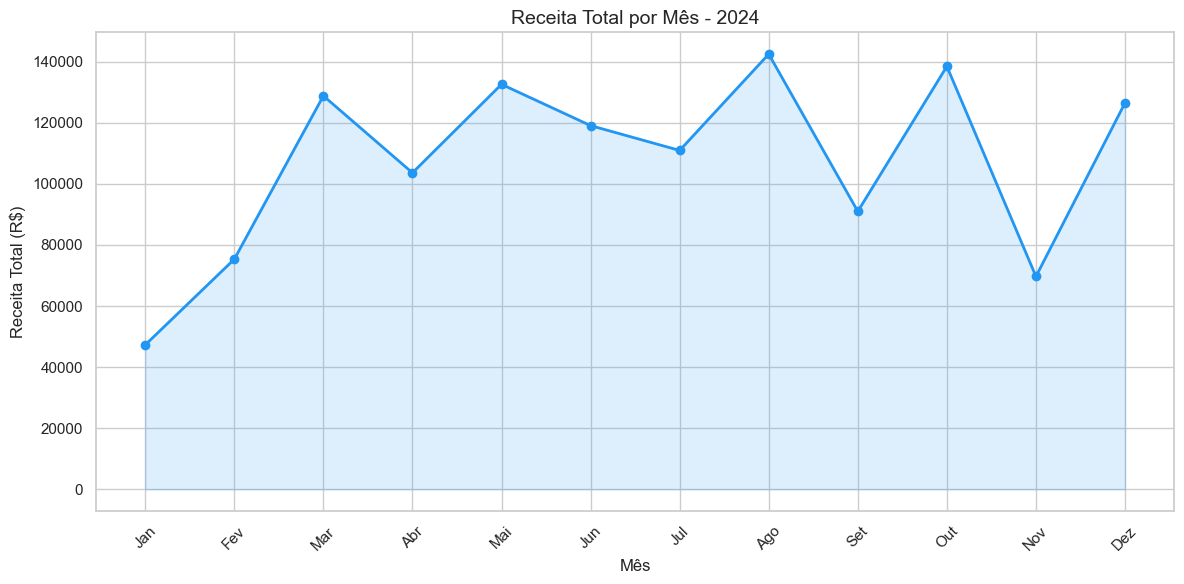

Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\renat\AppData\Local\Temp\ipykernel_22532\1160869401.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


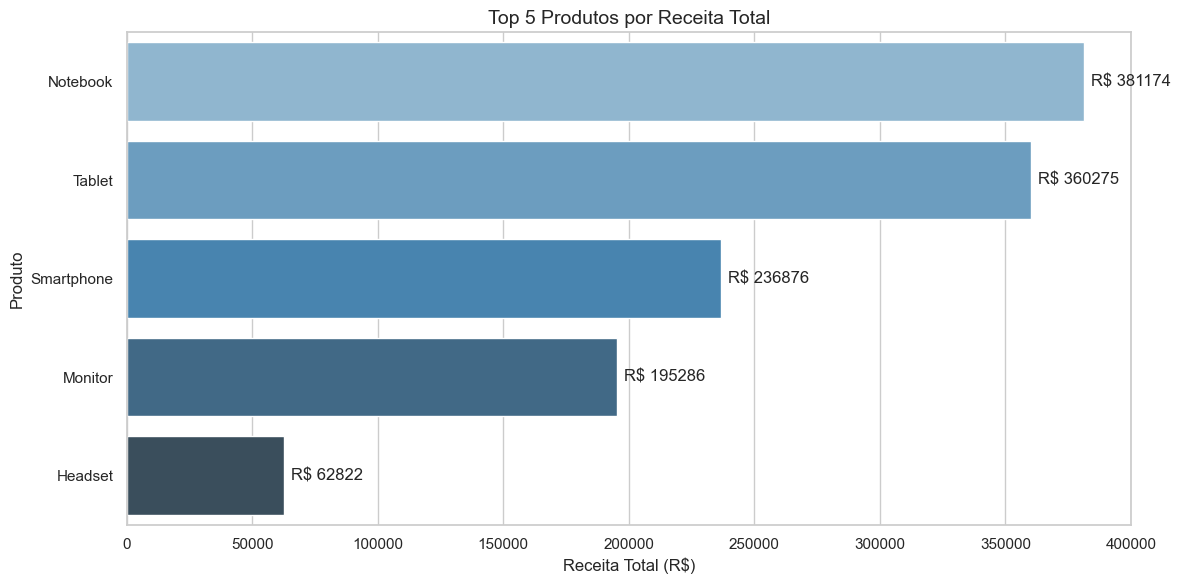

Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\renat\AppData\Local\Temp\ipykernel_22532\1160869401.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


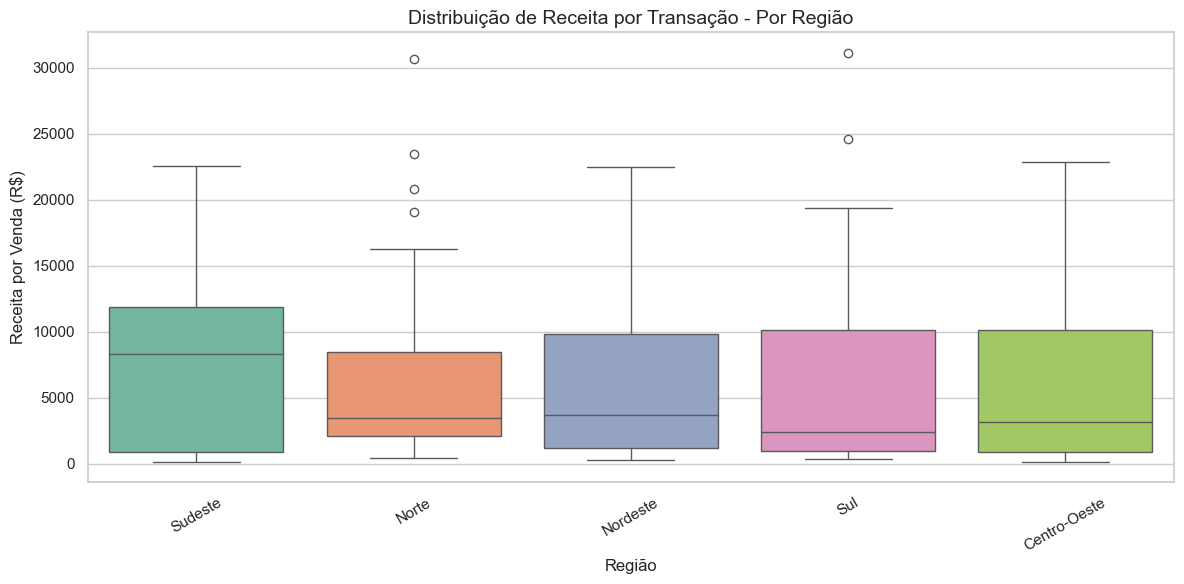

Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===

[AnalisadorDeVendas] Relatório exportado: outputs/relatorio_resumo.csv

=== LIMPEZA COM REGEX ===
Clientes com formato inválido encontrados: 0
Amostra de clientes limpos: ['Cliente_035', 'Cliente_042', 'Cliente_022', 'Cliente_017', 'Cliente_024']

=== ESTATÍSTICAS COM NUMPY ===
Receita média por venda: R$ 6559.66
Receita mediana por venda: R$ 3591.18
Desvio padrão: R$ 6625.37
Receita total: R$ 1285694.32
Percentil 25: R$ 1096.07
Percentil 75: R$ 10657.42

Receitas normalizadas — primeiros 5 valores:
[0.0024 0.0443 0.1512 0.3184 0.027 ]

Vendas acima da média: 78 de 196
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media": 6559.66,
  "mediana": 3591.18,
  "desvio_padrao": 6625.37,
  "total": 1285694.32,
  "percentil_25": 1096.07,
  "percentil_75": 10657.42


In [49]:
main()